# Achromobacter phage genomes

Visualising the gene similarity across these phage genomes in this notebook

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [ ]:
# prompt: pip install pygenomeviz - how do I run this as bash code to install a program
!pip install pygenomeviz
!apt install ncbi-blast+ mummer mmseqs2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  gawk libgzstream0 ncbi-data
Suggested packages:
  gawk-doc
The following NEW packages will be installed:
  gawk libgzstream0 mmseqs2 mummer ncbi-blast+ ncbi-data
0 upgraded, 6 newly installed, 0 to remove and 1 not upgraded.
Need to get 24.3 MB of archives.
After this operation, 110 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 gawk amd64 1:5.1.0-1ubuntu0.1 [447 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgzstream0 amd64 1.5+git20171107.9a20658-1 [7,410 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mmseqs2 amd64 13-45111+ds-2 [7,396 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/univer

In [ ]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.align import Blast, AlignCoord
from pygenomeviz.utils import load_example_genbank_dataset, is_pseudo_feature
from pygenomeviz.align import MUMmer
from pygenomeviz.align import MMseqs
from pathlib import Path
import pandas as pd

### Input files

Genbank files of each of the phage genomes. Save them to a folder

In this case these are the Genbank files generated from Sphae workflow https://github.com/linsalrob/sphae

In the below cell, change the name of the folder accordingly, and the file names.

Note: the file order in which you list them is the same order they will be visualised within the figure

In [ ]:
# prompt: genbank_dir = Path("genbank")
# gbk_files = [file for file in genbank_dir.iterdir() if file.suffix in (".gb", ".gbk")] - instead of this specificy the order in which the files will be read

genbank_dir = Path("genbank")
# Specify the order of files
gbk_files = [
    genbank_dir / "saurus_update2.gbk",
    genbank_dir / "turner_reoriented.gbk",
    genbank_dir / "gadget_reoriented.gbk",
    genbank_dir / "yaccob_reoriented.gbk",
    genbank_dir / "rage_reoriented.gbk",
    genbank_dir / "patchman_reoriented.gbk",
    genbank_dir / "viralious_reoriented.gbk",
    genbank_dir / "infector_update2.gbk",
    genbank_dir / "coliflower_update2.gbk",
    genbank_dir / "kuwaak_reoriented.gbk",
    genbank_dir / "ewik_update2.gbk",
    genbank_dir / "maay_reoriented.gbk",
    genbank_dir / "nyashin_update2.gbk",
    genbank_dir / "kwarr_update2.gbk",
    genbank_dir / "tuull_update3.gbk",
]

In [ ]:
#just checking all the phage genomes are being read correctly. The number should match the number of the phage genomes in the folder
gbk_list = list(map(Genbank, gbk_files))
len(gbk_files)

15

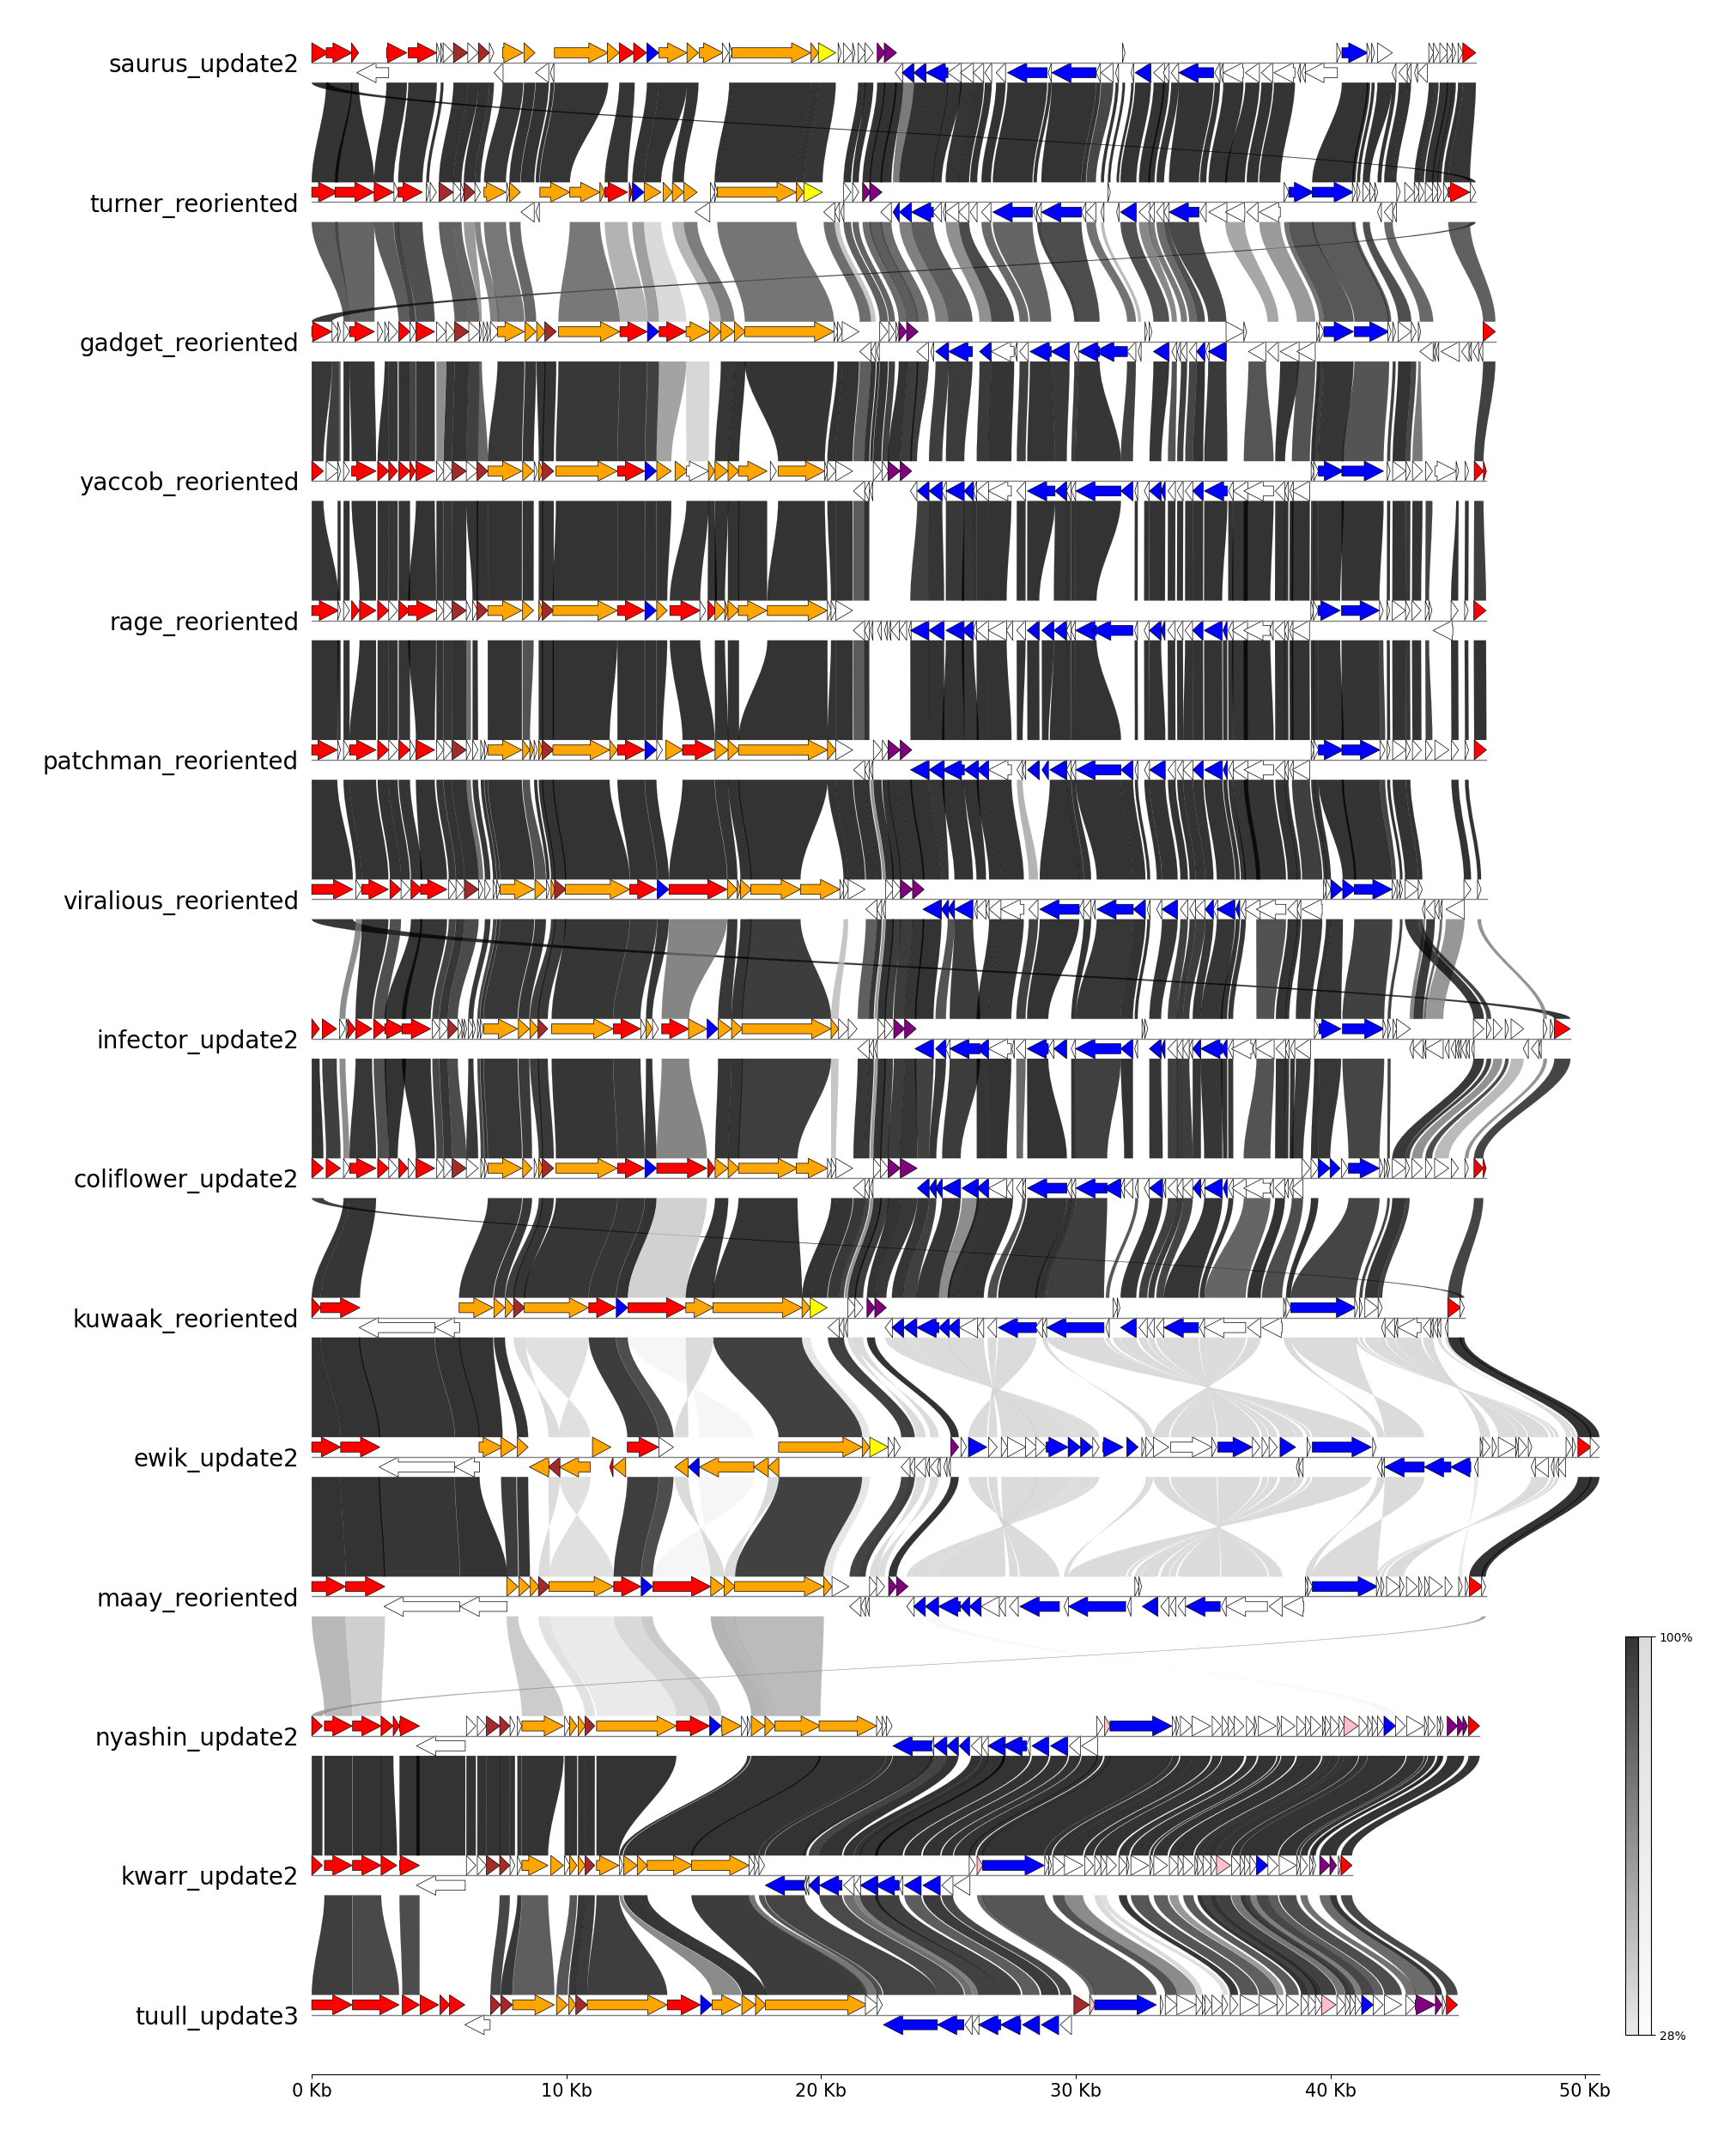

In [ ]:
#running mmseqs2 comparison
gv = GenomeViz(fig_track_height=0.8, feature_track_ratio=0.4)
gv.set_scale_xticks()

# Plot CDS features
for gbk in gbk_list:
    track = gv.add_feature_track(gbk.name, gbk.get_seqid2size(), align_label=False)
    for seqid, features in gbk.get_seqid2features("CDS").items():
        segment = track.get_segment(seqid)
        for feature in features:
            # Set user-defined feature color based on product name or function
            product = str(feature.qualifiers.get("product", [""])[0])
            function = str(feature.qualifiers.get("function", [""])[0])
            if function.startswith("unknown"):
                color = "white"
            elif function.startswith("DNA"):
                color = "blue"
            elif function.startswith("transcription"):
                color = "pink"
            elif function.startswith("moron"):
                color = "yellow"
            elif function.startswith("lysis"):
                color = "purple"
            elif function.startswith("tail"):
                color = "orange"
            elif function.startswith("connector"):
                color = "brown"
            elif function.startswith("head"):
                color = "red"
            elif function.startswith("integration"):
                color = "limegreen"

            segment.add_features(feature, fc=color, lw=0.5)

# Run MMseqs RBH search
align_coords = MMseqs(gbk_list).run()

# Plot MMseqs RBH search links
if len(align_coords) > 0:
    min_ident = int(min([ac.identity for ac in align_coords if ac.identity]))

    color, inverted_color = "black", "lightgrey"
    for ac in align_coords:
        gv.add_link(ac.query_link, ac.ref_link, color=color, inverted_color=inverted_color, v=ac.identity, vmin=min_ident, curve=True)
    gv.set_colorbar([color, inverted_color], vmin=min_ident)

fig = gv.plotfig()

### Aligning all pairs of phages

To generate a distance matrix, saved to DataFrame: `Phage_gene_matrix.csv`

This next block of code will take a long time, so be patient.

In [ ]:
# prompt: run item in gbk_list to the rest of the items in gbk_list, then move to the next item and do the same
seen_pairs = set()
align_coords=[]

for i in range(0, len(gbk_list)):
  for j in range(0, len(gbk_list)):
    # Perform comparison between gbk_list[i] and gbk_list[j]
    # Example using MMseqs:
    align_coords.append(MMseqs([gbk_list[i], gbk_list[j]]).run())
    print ([gbk_list[i].name, gbk_list[j].name])

In [ ]:
data=[]

for f in align_coords:
  for ac in f:
    data.append({
        'queryID': ac.query_id,
        'query_name': ac.query_name,
        'qstart': ac.query_start,
        'qend': ac.query_end,
        'refID': ac.ref_id,
        'ref_name': ac.ref_name,
        'rstart': ac.ref_start,
        'rend': ac.ref_end,
        'identity': ac.identity,
        'evalue': ac.evalue
    })
df=pd.DataFrame(data)
df

In [ ]:
# prompt: for each of the queryID, find the genabnk file, match the qstart and qend - get product name in genbank file and save to a new column qproduct

df['qproduct'] = ''  # Initialize a new column for query product
df['qgeneID'] = ''  # Initialize a new column for query product

df['rproduct'] = ''  # Initialize a new column for query product
df['rgeneID'] = ''  # Initialize a new column for query product


for index, row in df.iterrows():
  query_id = row['queryID']
  qstart = row['qstart']
  qend = row['qend']

  for gbk in gbk_list:
    if gbk.name == query_id:
      # Extract features for the current genbank file
      qgbk=Genbank('genbank/'+ gbk.name + '.gbk')
      features = qgbk.extract_features()
      for feature in features:
        if feature.location.start <= qstart and feature.location.end >= qend:
          df.at[index, 'qproduct'] = feature.qualifiers.get('product', [''])[0]
          df.at[index, 'qgeneID'] = feature.qualifiers.get('ID', [''])[0]
          break  # Move to next row once product is found

for index, row in df.iterrows():
  ref_id = row['refID']
  rstart = row['rstart']
  rend = row['rend']


  for gbk in gbk_list:
    if gbk.name == ref_id:
      # Extract features for the current genbank file
      rgbk=Genbank('genbank/'+ gbk.name + '.gbk')
      features = rgbk.extract_features()
      for feature in features:
        if feature.location.start <= rstart and feature.location.end >= rend:
          df.at[index, 'rproduct'] = feature.qualifiers.get('product', [''])[0]
          df.at[index, 'rgeneID'] = feature.qualifiers.get('ID', [''])[0]
          break  # Move to next row once product is found

df

In [ ]:
# prompt: if qgeneID and rgeneID are the same remove the row

df_filtered = df[df['qgeneID'] != df['rgeneID']]
df_filtered


In [ ]:
# prompt: merge text in columns query_ID to qgeneID to a new column to the above dataframe

df_filtered['merged_query'] = df_filtered.apply(lambda row: f"{row['queryID']} - {row['qgeneID']}", axis=1)
df_filtered['merged_query_name'] = df_filtered.apply(lambda row: f"{row['merged_query']} - {row['qproduct']}", axis=1)
df_filtered['merged_ref'] = df_filtered.apply(lambda row: f"{row['refID']} - {row['rgeneID']}", axis=1)
df_filtered['merged_ref_name'] = df_filtered.apply(lambda row: f"{row['merged_ref']} - {row['rproduct']}", axis=1)
df_filtered

In [ ]:
# prompt: write the df into a csv file

df_filtered.to_csv('Phage_gene_matrix.csv', index=False)


The above file `Phage_gene_matrix.csv` can be input for other donwstream analysis

##Replotting with just the tail associated genes

Fig S2


In [ ]:
gene_matrix =pd.read_csv("Phage_tail_clusters_WClusterID.tsv", sep="\t")
gene_matrix

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value,gene,cluster
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0,AXUUMYTS_CDS_0018,cluster_2
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,1,AXUUMYTS_CDS_0018,cluster_2
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,1,AXUUMYTS_CDS_0018,cluster_2
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1,AXUUMYTS_CDS_0018,cluster_2
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,1,AXUUMYTS_CDS_0018,cluster_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A xylosoxidans suz,1,YRFTTTDG_CDS_0020,cluster_8
2180,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus vya,1,YRFTTTDG_CDS_0020,cluster_8
2181,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus neet,1,YRFTTTDG_CDS_0020,cluster_8
2182,tuull,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,tuull - YRFTTTDG_CDS_0020,tuull - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,tuull,A insolitus aura,0,YRFTTTDG_CDS_0020,cluster_8


In [ ]:
gene_matrix['cluster'].unique()

array(['cluster_2', 'cluster_1', nan, 'cluster_3', 'cluster_4',
       'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8'], dtype=object)

In [ ]:
allq=set(gene_matrix['qgeneID'].unique())

len(allq)

46

In [ ]:
# For each cluster, get unique rgeneID and qgeneID combined

# 👇 define colors *by cluster name*
cluster_to_genes = (
    combined_with_clusters
    .groupby("cluster")["qgeneID"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genes
# Check result
for cluster, genes in cluster_to_locus.items():
    print(cluster, len(genes), genes[:10])  # show first 10 genes


cluster_1 19 ['AXUUMYTS_CDS_0021', 'BUBCVPIM_CDS_0027', 'IFXVGPNG_CDS_0032', 'IHDRJJQR_CDS_0034', 'JDOEVDKM_CDS_0028', 'JDOEVDKM_CDS_0029', 'JJIYCMYV_CDS_0023', 'JZFESBBW_CDS_0030', 'JZFESBBW_CDS_0032', 'LDQZVDBU_CDS_0031']
cluster_2 12 ['AXUUMYTS_CDS_0018', 'IFXVGPNG_CDS_0027', 'IFXVGPNG_CDS_0028', 'IHDRJJQR_CDS_0029', 'JDOEVDKM_CDS_0024', 'JZFESBBW_CDS_0024', 'JZFESBBW_CDS_0026', 'MOJOLAXZ_CDS_0024', 'OKILJAZK_CDS_0012', 'QLZSKYRQ_CDS_0029']
cluster_3 8 ['AXUUMYTS_CDS_0018', 'IFXVGPNG_CDS_0027', 'IHDRJJQR_CDS_0028', 'JZFESBBW_CDS_0024', 'MOJOLAXZ_CDS_0023', 'OKILJAZK_CDS_0012', 'QLZSKYRQ_CDS_0027', 'YRFTTTDG_CDS_0017']
cluster_4 11 ['AXUUMYTS_CDS_0018', 'IFXVGPNG_CDS_0027', 'IHDRJJQR_CDS_0029', 'JDOEVDKM_CDS_0024', 'JZFESBBW_CDS_0024', 'MOJOLAXZ_CDS_0024', 'MPKKVJWZ_CDS_0012', 'OKILJAZK_CDS_0012', 'QLZSKYRQ_CDS_0029', 'VNLSRWGA_CDS_0023']
cluster_5 14 ['AXUUMYTS_CDS_0021', 'BUBCVPIM_CDS_0027', 'IFXVGPNG_CDS_0032', 'IHDRJJQR_CDS_0034', 'JDOEVDKM_CDS_0028', 'JJIYCMYV_CDS_0023', 'LDQZVD

In [ ]:
# For each cluster, get unique rgeneID and qgeneID combined
cluster_colors = {
    "cluster_1": "#6a329f",  #purple
    "cluster_2": "#c90076",  # pink
    "cluster_7": "#16537e",  # blue
    "cluster_4": "#ce7e00",  # orange
    "cluster_5": "#8fce00",  # green
    "cluster_6": "#744700",  # brown
    "cluster_3": "#f44336",  # red
    "cluster_8": "#28c8d7",  # lightblue
}

cluster_info = {}

for cluster, genes in cluster_to_genes.items():
    cluster_info[cluster] = {
        "color": cluster_colors.get(cluster, "#cccccc"),  # fallback gray
        "genes": genes
    }

# Check result
for cluster, info in cluster_info.items():
    print(cluster, info["color"], len(info["genes"]), info["genes"][:10])

cluster_1 #6a329f 14 ['AXUUMYTS_CDS_0021', 'IFXVGPNG_CDS_0032', 'IHDRJJQR_CDS_0034', 'JDOEVDKM_CDS_0028', 'JDOEVDKM_CDS_0029', 'JZFESBBW_CDS_0030', 'JZFESBBW_CDS_0032', 'MOJOLAXZ_CDS_0030', 'MOJOLAXZ_CDS_0031', 'MPKKVJWZ_CDS_0014']
cluster_2 #c90076 7 ['AXUUMYTS_CDS_0018', 'IHDRJJQR_CDS_0029', 'JDOEVDKM_CDS_0024', 'JZFESBBW_CDS_0026', 'MOJOLAXZ_CDS_0024', 'QLZSKYRQ_CDS_0029', 'VNLSRWGA_CDS_0023']
cluster_3 #f44336 4 ['IHDRJJQR_CDS_0028', 'JZFESBBW_CDS_0024', 'MOJOLAXZ_CDS_0023', 'QLZSKYRQ_CDS_0027']
cluster_4 #ce7e00 2 ['MPKKVJWZ_CDS_0012', 'OKILJAZK_CDS_0012']
cluster_5 #8fce00 2 ['LDQZVDBU_CDS_0031', 'VCKTMGAM_CDS_0029']
cluster_6 #744700 1 ['LDQZVDBU_CDS_0033']
cluster_7 #16537e 2 ['BUBCVPIM_CDS_0027', 'JJIYCMYV_CDS_0023']
cluster_8 #28c8d7 3 ['BUBCVPIM_CDS_0028', 'JJIYCMYV_CDS_0024', 'YRFTTTDG_CDS_0020']


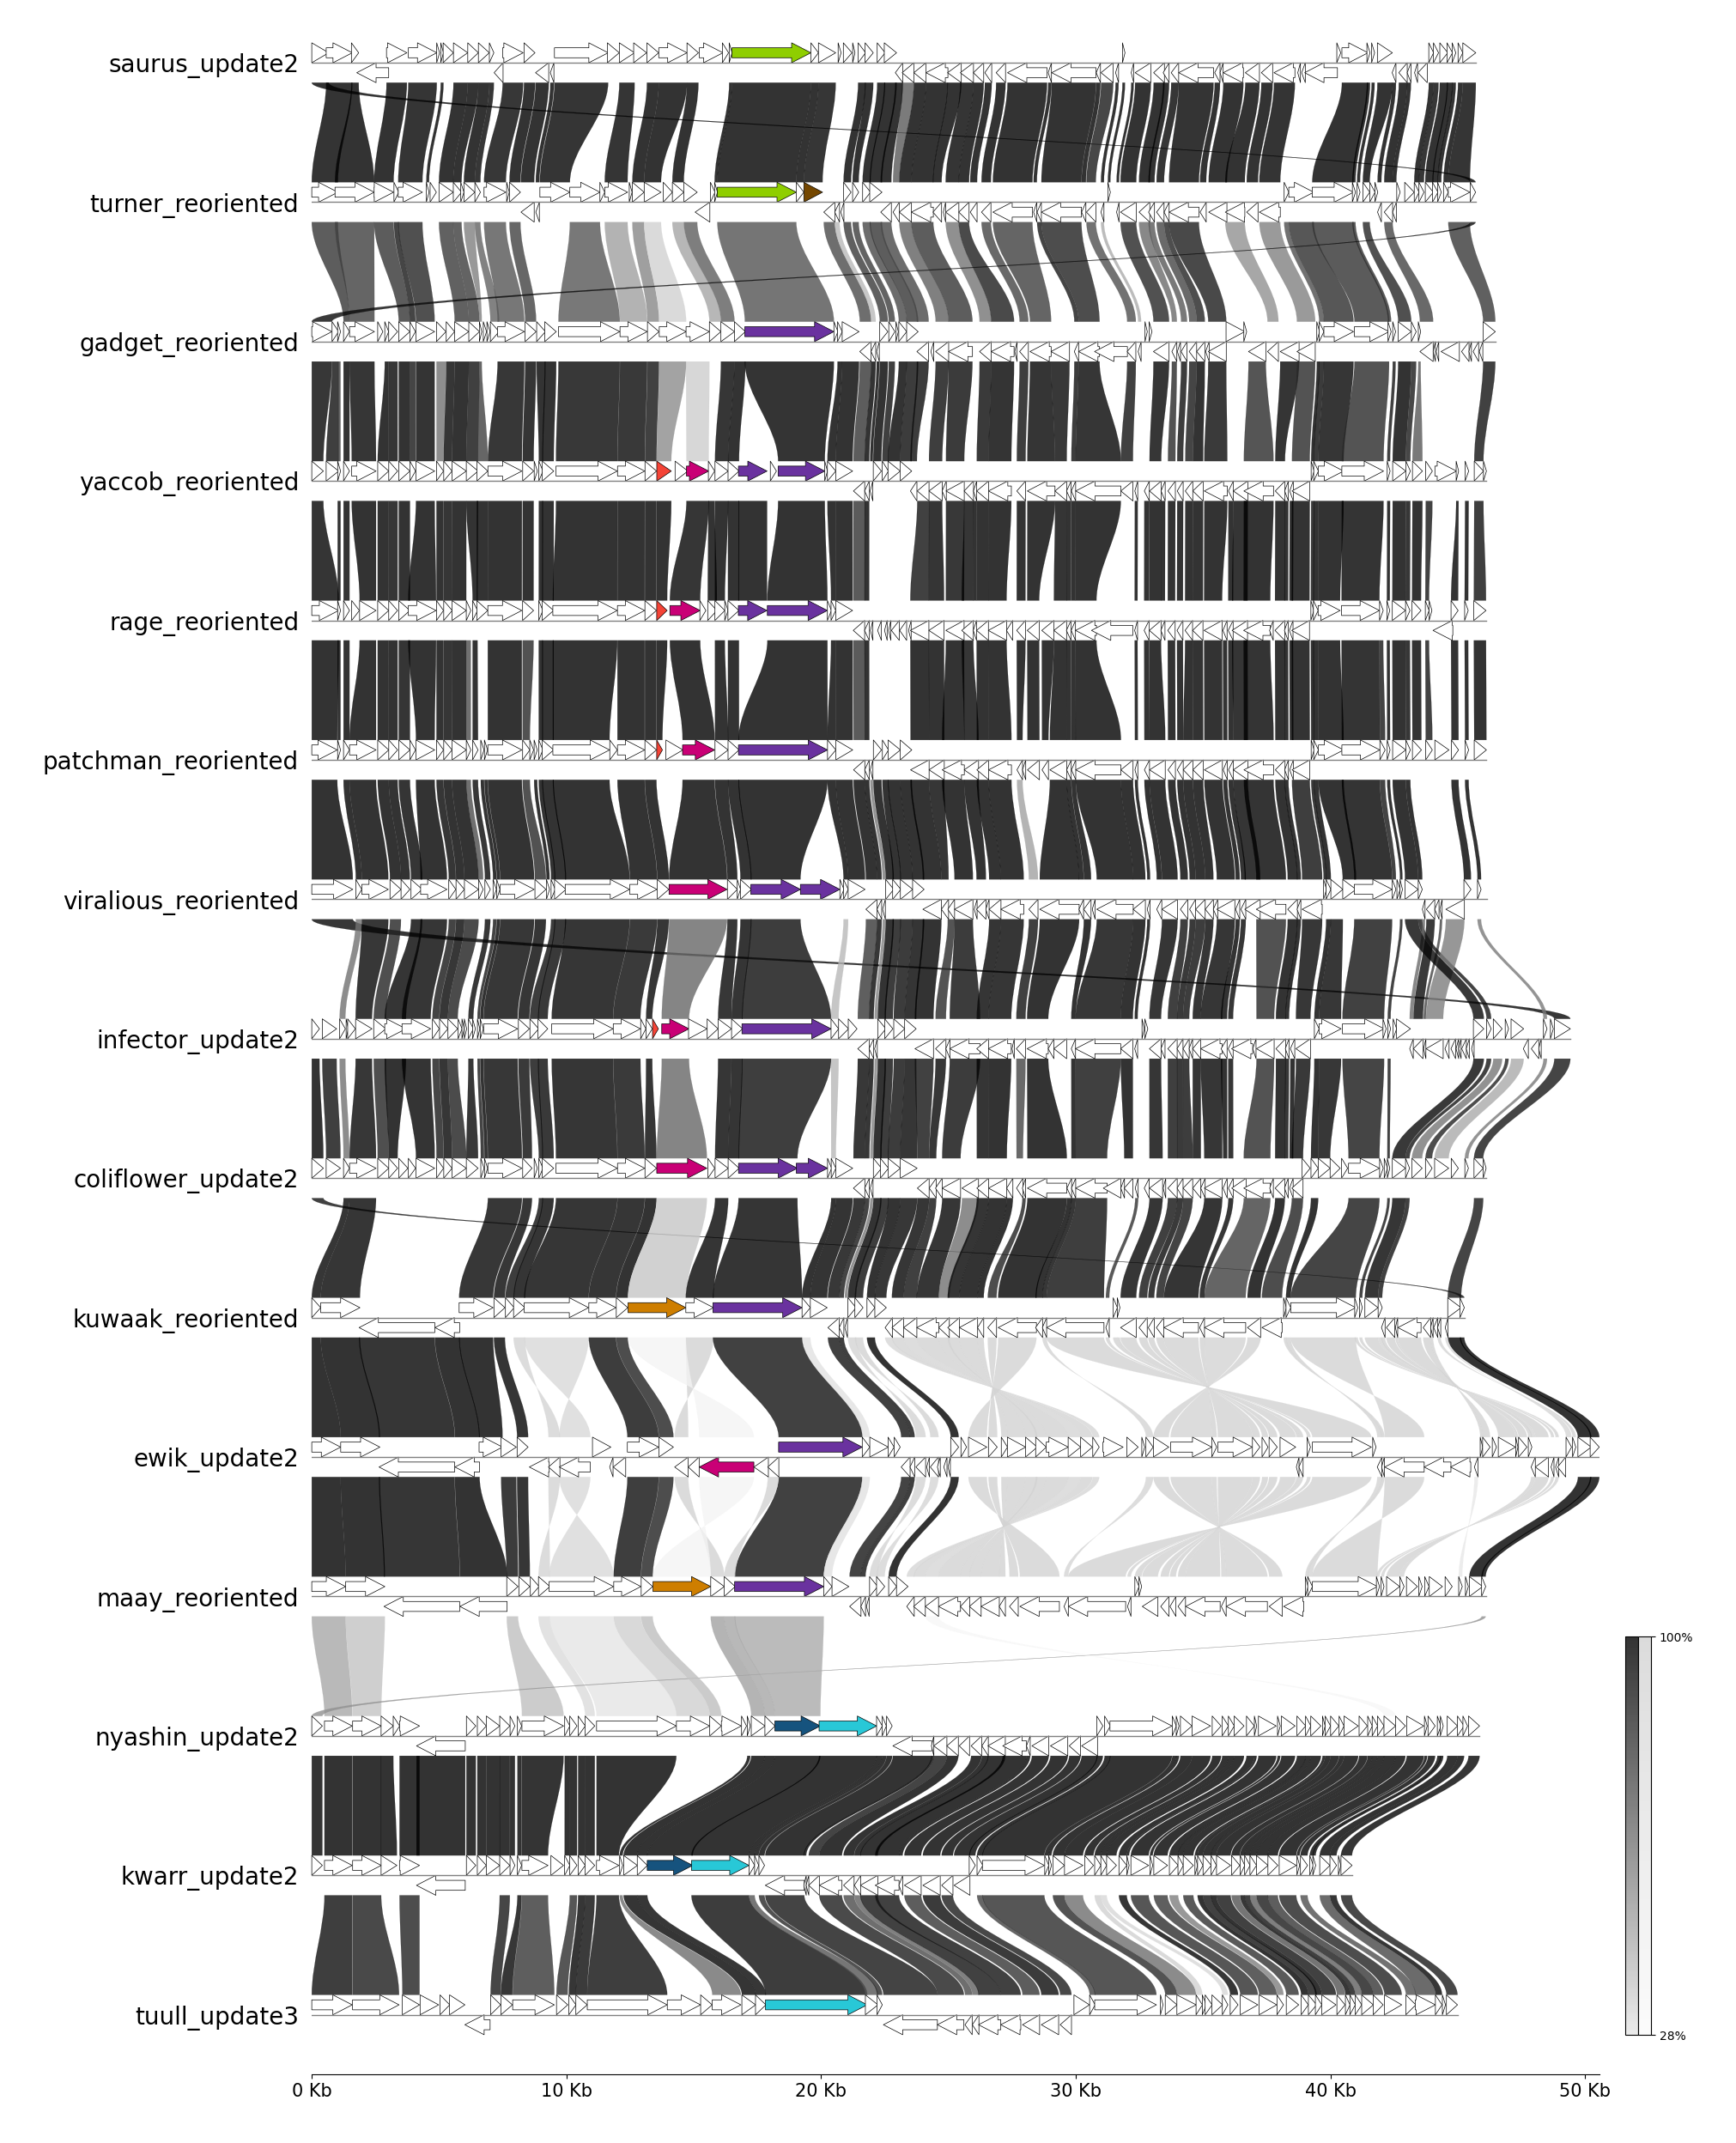

In [ ]:
#running mmseqs2 comparison
gv = GenomeViz(fig_track_height=0.8, feature_track_ratio=0.4)
gv.set_scale_xticks()

# Plot CDS features
for gbk in gbk_list:
    track = gv.add_feature_track(
        gbk.name,
        gbk.get_seqid2size(),
        align_label=False
    )

    for seqid, features in gbk.get_seqid2features("CDS").items():
        segment = track.get_segment(seqid)

        for feature in features:
            locus_tag = str(feature.qualifiers.get("locus_tag", [""])[0]).strip()

            # Color by cluster membership, else white
            color = rgene_to_color.get(locus_tag, "white")

            segment.add_features(feature, fc=color, lw=0.5)

# =========================
# Run MMseqs2 RBH search
# =========================

align_coords = MMseqs(gbk_list).run()

# Plot MMseqs2 links
if len(align_coords) > 0:
    min_ident = int(min(ac.identity for ac in align_coords if ac.identity))

    for ac in align_coords:
        gv.add_link(
            ac.query_link,
            ac.ref_link,
            color="black",
            inverted_color="lightgrey",
            v=ac.identity,
            vmin=min_ident,
            curve=True
        )

    gv.set_colorbar(["black", "lightgrey"], vmin=min_ident)

# =========================
# Render figure
# =========================

fig = gv.plotfig()


In [ ]:


# Plot CDS features
for gbk in gbk_list:
    track = gv.add_feature_track(
        gbk.name,
        gbk.get_seqid2size(),
        align_label=False
    )

    for seqid, features in gbk.get_seqid2features("CDS").items():
        segment = track.get_segment(seqid)

        for feature in features:
            locus_tag = str(feature.qualifiers.get("locus_tag", [""])[0]).strip()

            # Color by cluster membership, else white
            color = rgene_to_color.get(locus_tag, "white")

            segment.add_features(feature, fc=color, lw=0.5)

# =========================
# Run MMseqs2 RBH search
# =========================

align_coords = MMseqs(gbk_list).run()

# Plot MMseqs2 links
if len(align_coords) > 0:
    min_ident = int(min(ac.identity for ac in align_coords if ac.identity))

    for ac in align_coords:
        gv.add_link(
            ac.query_link,
            ac.ref_link,
            color="black",
            inverted_color="lightgrey",
            v=ac.identity,
            vmin=min_ident,
            curve=True
        )

    gv.set_colorbar(["black", "lightgrey"], vmin=min_ident)

# =========================
# Render figure
# =========================

fig = gv.plotfig()
